# This Notebook is used to create a visual representation of the camera trajectories

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image
import os

In [2]:
poses=[]
folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/odom_poses'
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count}")
for i in range(0,file_count,1):
    filename = filename=folder_path+f"/odom__{i:04d}.txt"
    matrix = []
    with open(filename, 'r') as file:
        for line in file:
            # Skip empty lines
            if line.strip() and not line.startswith('u'):
                # Split the line by whitespace and convert each element to float
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)
    temp = np.array(matrix[0:4])
    poses.append(np.array(matrix[0:4]))
poses=np.array(poses)

Number of files: 908


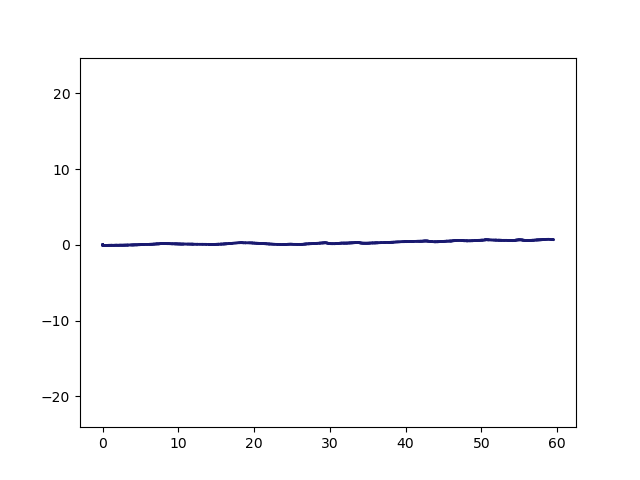

In [3]:
%matplotlib ipympl
origins = poses[:, :3, -1]
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in poses])
x= origins[..., 0].flatten()
y= origins[..., 1].flatten()
z= origins[..., 2].flatten()
#print(np.array(x))
# print(type(x))
s = np.ones(len(x))
#plt.scatter(x=x, y=y, color='red')
# plt.xlim(0, 35)   
# plt.ylim(0, 8) 
plt.axis('equal')
plt.scatter(x, y, s=s, color='midnightblue', label='Group 1')
plt.show()

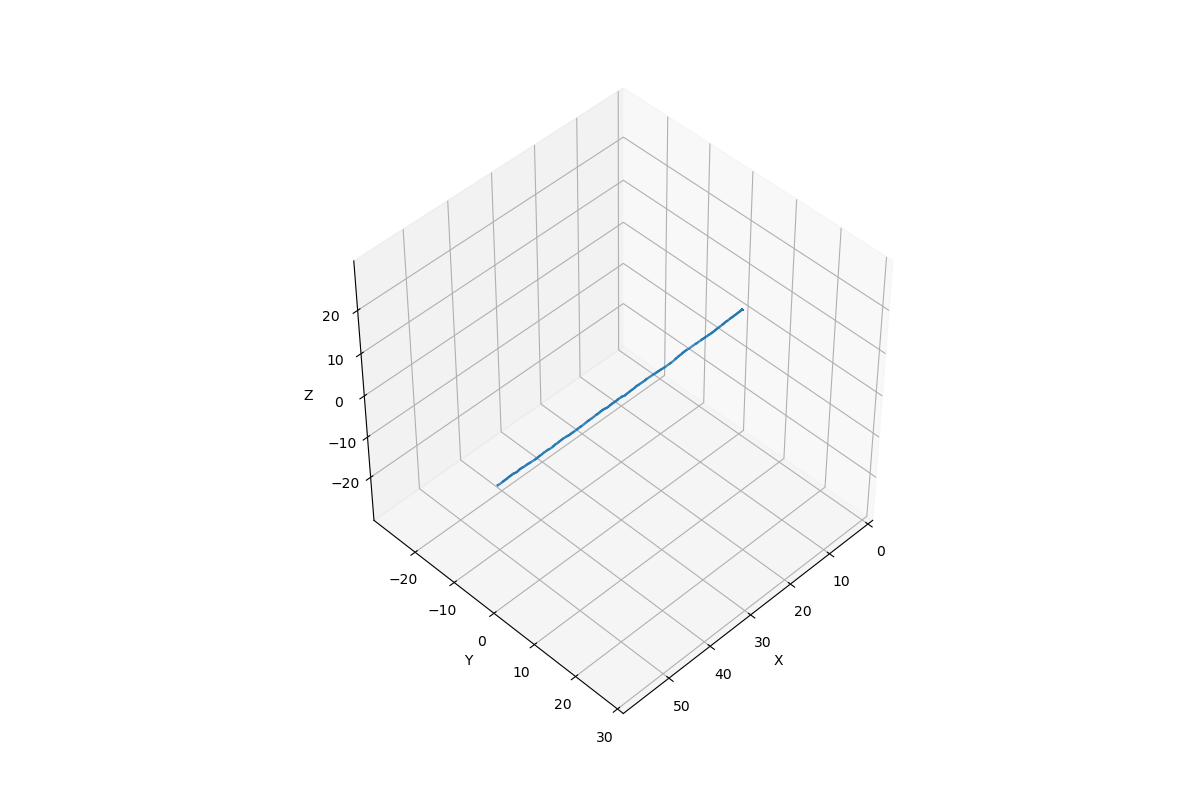

In [6]:
%matplotlib ipympl

# print(origins)

all_points = np.concatenate([origins.reshape(-1, 3),
                              origins.reshape(-1, 3) + dirs.reshape(-1, 3) * 0.1])

# Get the range
x_min, y_min, z_min = all_points.min(axis=0)
x_max, y_max, z_max = all_points.max(axis=0)

# Determine the largest range
max_range = max(x_max - x_min, y_max - y_min, z_max - z_min) / 2

# Find the midpoints
mid_x = (x_max + x_min) / 2
mid_y = (y_max + y_min) / 2
mid_z = (z_max + z_min) / 2



ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  dirs[..., 0].flatten(),
  dirs[..., 1].flatten(),
  dirs[..., 2].flatten(), length=0.1, normalize=True)
ax.set_box_aspect([1,1,1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# Apply equal limits
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
ax.view_init(45, 45) 
plt.show()

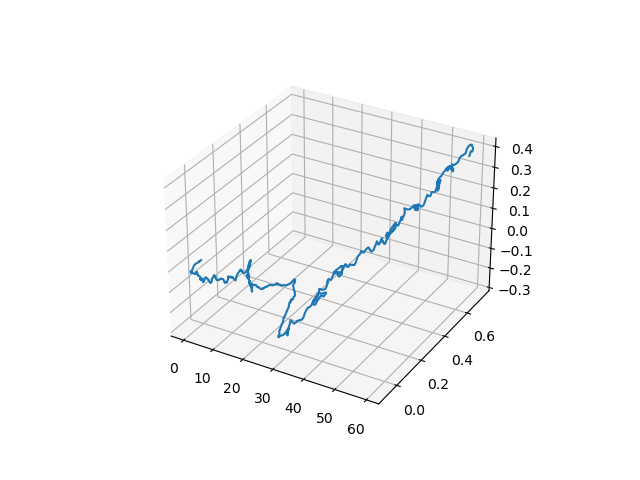

In [5]:
%matplotlib ipympl
ax = plt.axes(projection='3d')
ax.plot3D(x, y, z)